# Nowify – Procrastination Model Training

This notebook trains the procrastination risk model used by the Flask API.

- **Data:** OULAD from `ml/dataset/` (see optional cells).
- **Pipeline:** Cell 1 runs `ml/train_model_final.py` (OULAD from ml/dataset). The rest: optional EDA, then **OULAD preprocessing** (Steps 1–5) and EDA of the final dataset. To train, run Setup then Steps 1–5, or run `python ml/train_model_final.py` from project root.
- **Output:** `ml/model/procrastination_model.joblib`, `ml/features.txt` (must match Next.js `lib/featureVector.ts` and Flask `/predict`).

In [1]:
# Run from project root so model and features save to ml/model/ and ml/features.txt
import os
# If we're in ml/notebooks/, go up twice to project root
_cwd = os.getcwd()
if _cwd.endswith('notebooks') or 'notebooks' in _cwd.replace('\\', '/').split('/'):
    project_root = os.path.abspath(os.path.join(_cwd, '..', '..'))
else:
    project_root = _cwd
if os.path.isfile(os.path.join(project_root, 'ml', 'train_model_final.py')):
    os.chdir(project_root)
print("CWD:", os.getcwd())

# Run the training script (synthetic data by default; outputs model + features.txt)
%run ml/train_model_final.py

CWD: d:\workspace\2025_2026\Second term\KKU\CS\LMS\LMS_SYSTEM
Dataset path: d:\workspace\2025_2026\Second term\KKU\CS\LMS\LMS_SYSTEM\ml\dataset
Step 1 done. studentInfo: (32593, 12)
Step 2 done. agg_sub: (25843, 9)
Step 3 done. vle_early: (28842, 6)
Step 4 done. prep: (32593, 28)
Step 5 done. X: (28785, 10) y: (28785,)
Label distribution: {0: 16547, 1: 12238}
Logistic Regression F1: 0.610726643598616 | {'accuracy': 0.6873371547681084, 'precision': 0.6491954022988505, 'recall': 0.5765618619844834, 'f1': 0.610726643598616, 'confusion_matrix': [[2545, 763], [1037, 1412]]}
Random Forest F1: 0.7320966350301984 | {'accuracy': 0.7842626367899947, 'precision': 0.7759487882944673, 'recall': 0.6929358922008984, 'f1': 0.7320966350301984, 'confusion_matrix': [[2818, 490], [752, 1697]]}
XGBoost F1: 0.742995808515332 | {'accuracy': 0.7976376585026924, 'precision': 0.8080614203454894, 'recall': 0.6876276031033075, 'f1': 0.742995808515332, 'confusion_matrix': [[2908, 400], [765, 1684]]}
Saved: d:\work

## Optional: Inspect local OULAD dataset (`ml/dataset/`)

The folder contains: `studentInfo.csv`, `studentAssessment.csv`, `assessments.csv`, `studentVle.csv`, `studentRegistration.csv`, `courses.csv`, `vle.csv`.  
To train on this data, run the preprocessing cells below (Steps 1–5) or run `python ml/train_model_final.py` from project root.

## EDA – Exploratory Data Analysis (all dataset files)

The following cells load each file in `ml/dataset/` and show: **shape**, **dtypes**, **missing values**, **head**, **describe** (numeric), and **value_counts** for key categorical columns. Use this to understand OULAD structure before building features for the procrastination model.

In [2]:
# Setup: locate ml/dataset and list files
import os
import pandas as pd

cwd = os.getcwd()
ds = None
for base in [cwd, os.path.join(cwd, ".."), os.path.join(cwd, "..", "..")]:
    candidate = os.path.join(os.path.abspath(base), "ml", "dataset")
    if os.path.isfile(os.path.join(candidate, "studentInfo.csv")):
        ds = candidate
        break
if not ds:
    raise FileNotFoundError(
        "ml/dataset not found. Set CWD to project root or ml/notebooks."
    )

print("Dataset path:", ds)
print("\nFiles and sizes:")
for f in sorted(os.listdir(ds)):
    path = os.path.join(ds, f)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"  {f}: {size_mb:.2f} MB" if size_mb >= 0.01 else f"  {f}: <0.01 MB")

Dataset path: d:\workspace\2025_2026\Second term\KKU\CS\LMS\LMS_SYSTEM\ml\dataset

Files and sizes:
  assessments.csv: <0.01 MB
  courses.csv: <0.01 MB
  studentAssessment.csv: 5.43 MB
  studentInfo.csv: 3.30 MB
  studentRegistration.csv: 1.06 MB
  studentVle.csv: 432.81 MB
  vle.csv: 0.25 MB


In [3]:
# --- 1. studentInfo.csv ---
# One row per student per module: demographics, education, final_result (Pass/Fail/Withdrawn)
df = pd.read_csv(os.path.join(ds, "studentInfo.csv"))
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING per column:\n", df.isnull().sum())
print("\nHEAD(10):")
display(df.head(10))
print("\nDESCRIBE (numeric):")
display(df.describe(include="number"))
print("\nVALUE_COUNTS: final_result")
print(df["final_result"].value_counts(dropna=False))
print("\nVALUE_COUNTS: gender")
print(df["gender"].value_counts(dropna=False))
print("\nVALUE_COUNTS: highest_education (top 5)")
print(df["highest_education"].value_counts(dropna=False).head(5))

SHAPE: (32593, 12)

DTYPES:
 code_module               str
code_presentation         str
id_student              int64
gender                    str
region                    str
highest_education         str
imd_band                  str
age_band                  str
num_of_prev_attempts    int64
studied_credits         int64
disability                str
final_result              str
dtype: object

MISSING per column:
 code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

HEAD(10):


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,N,Pass
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,N,Pass
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,N,Pass
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,NaN,55<=,0,60,N,Pass



DESCRIBE (numeric):


,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000



VALUE_COUNTS: final_result
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

VALUE_COUNTS: gender
gender
M    17875
F    14718
Name: count, dtype: int64

VALUE_COUNTS: highest_education (top 5)
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64


In [4]:
# --- 2. studentRegistration.csv ---
# date_registration: The date of student’s registration on the module presentation,this is the number
# of days measured relative to the start of the module-presentation
# (e.g. the negative value -30 means that the student registered to module presentation 30 days before it started).

# date_unregistration:
# The number of days (relative to the start of the module-presentation) when the student unregistered
# from a module.This field is empty for students who completed the course.
# Students who have a value here (i.e., who unregistered) have "Withdrawn" as their final_result
# in studentInfo.csv.


# Registration and unregistration dates per student per module (days relative to course start)

df = pd.read_csv(os.path.join(ds, "studentRegistration.csv"))

print("SHAPE:", df.shape)

print("\nDTYPES:\n", df.dtypes)

print("\nMISSING per column:\n", df.isnull().sum())

print("\nHEAD(10):")

display(df.head(10))

print("\nDESCRIBE (numeric):")

display(df.describe(include="number"))
print(
    "\ndate_registration: min/max (days)",
    df["date_registration"].min(),
    df["date_registration"].max(),
)
print(
    "date_unregistration non-null count(Withdrawn):",
    df["date_unregistration"].notna().sum(),
)
print(
    "\ndate_unregistration: min/max (days)",
    df["date_unregistration"].min(),
    df["date_unregistration"].max(),
)

SHAPE: (32593, 5)

DTYPES:
 code_module                str
code_presentation          str
id_student               int64
date_registration      float64
date_unregistration    float64
dtype: object

MISSING per column:
 code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64

HEAD(10):


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN
5,AAA,2013J,38053,-110.0,NaN
6,AAA,2013J,45462,-67.0,NaN
7,AAA,2013J,45642,-29.0,NaN
8,AAA,2013J,52130,-33.0,NaN
9,AAA,2013J,53025,-179.0,NaN



DESCRIBE (numeric):


,id_student,date_registration,date_unregistration
count,3.259300e+04,32548.000000,10072.000000
mean,7.066877e+05,-69.411300,49.757645
std,5.491673e+05,49.260522,82.460890
min,3.733000e+03,-322.000000,-365.000000
25%,5.085730e+05,-100.000000,-2.000000
50%,5.903100e+05,-57.000000,27.000000
75%,6.444530e+05,-29.000000,109.000000
max,2.716795e+06,167.000000,444.000000



date_registration: min/max (days) -322.0 167.0
date_unregistration non-null count(Withdrawn): 10072

date_unregistration: min/max (days) -365.0 444.0


In [5]:
# --- 3. assessments.csv ---
# Assessment definitions per module: type (TMA/CMA/Exam), date (deadline), weight
# Three types of assessments exist:
# Tutor Marked Assessment (TMA),Computer Marked Assessment (CMA) and Final Exam (Exam).
# date is the date of the assessment deadline.(calculated as the number of days since the start of the module-presentation.)
# weight is the weight of the assessment in the final grade.(Weight of the assessment in %. Typically, Exams are treated separately and have the weight 100%; the sum of all other assessments is 100%.)
df = pd.read_csv(os.path.join(ds, "assessments.csv"))
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING per column:\n", df.isnull().sum())
print("\nHEAD(15):")
display(df.head(15))
print("\nVALUE_COUNTS: assessment_type")
print(df["assessment_type"].value_counts(dropna=False))
print("\nDESCRIBE (numeric):")
display(df.describe(include="number"))

SHAPE: (206, 6)

DTYPES:
 code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

MISSING per column:
 code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

HEAD(15):


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0
5,AAA,2013J,1757,Exam,NaN,100.0
6,AAA,2014J,1758,TMA,19.0,10.0
7,AAA,2014J,1759,TMA,54.0,20.0
8,AAA,2014J,1760,TMA,117.0,20.0
9,AAA,2014J,1761,TMA,166.0,20.0



VALUE_COUNTS: assessment_type
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

DESCRIBE (numeric):


,id_assessment,date,weight
count,206.000000,195.000000,206.000000
mean,26473.975728,145.005128,20.873786
std,10098.625521,76.001119,30.384224
min,1752.000000,12.000000,0.000000
25%,15023.250000,71.000000,0.000000
50%,25364.500000,152.000000,12.500000
75%,34891.750000,222.000000,24.250000
max,40088.000000,261.000000,100.000000


In [6]:
# --- 4. studentAssessment.csv ---
# Submissions: id_assessment, id_student, date_submitted, is_banked,
# score (for procrastination: compare date_submitted to assessment deadline)
df = pd.read_csv(os.path.join(ds, "studentAssessment.csv"))
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING per column:\n", df.isnull().sum())
print("\nHEAD(10):")
display(df.head(10))
print("\nDESCRIBE (numeric):")
display(df.describe(include="number"))
print("\nScore: value_counts (binned)")
print(
    pd.cut(
        df["score"],
        bins=[0, 40, 60, 80, 100],
        labels=["0-40", "40-60", "60-80", "80-100"],
    )
    .value_counts()
    .sort_index()
)

SHAPE: (173912, 5)

DTYPES:
 id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object

MISSING per column:
 id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

HEAD(10):


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
5,1752,45462,20,0,70.0
6,1752,45642,18,0,72.0
7,1752,52130,19,0,72.0
8,1752,53025,9,0,71.0
9,1752,57506,18,0,68.0



DESCRIBE (numeric):


,id_assessment,id_student,date_submitted,is_banked,score
count,173912.000000,1.739120e+05,173912.000000,173912.000000,173739.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977,75.799573
std,8829.784254,5.523952e+05,71.484148,0.104194,18.798107
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000,65.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000,80.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000



Score: value_counts (binned)
score
0-40       9215
40-60     23962
60-80     64672
80-100    75561
Name: count, dtype: int64


In [7]:
# --- 5. studentVle.csv ---
# VLE activity: id_student, id_site, date (relative days), sum_click (proxy for login/engagement)
df = pd.read_csv(os.path.join(ds, "studentVle.csv"))
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING per column:\n", df.isnull().sum())
print("\nHEAD(10):")
display(df.head(10))
print("\nDESCRIBE (numeric):")
display(df.describe(include="number"))
# Clicks per student (sample)
clicks_per_student = df.groupby("id_student")["sum_click"].sum()
print(
    "\nClicks per student (sample stats): count=",
    clicks_per_student.count(),
    "mean=",
    clicks_per_student.mean().round(2),
    "median=",
    clicks_per_student.median(),
)

SHAPE: (10655280, 6)

DTYPES:
 code_module            str
code_presentation      str
id_student           int64
id_site              int64
date                 int64
sum_click            int64
dtype: object

MISSING per column:
 code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

HEAD(10):


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
5,AAA,2013J,28400,546652,-10,8
6,AAA,2013J,28400,546876,-10,2
7,AAA,2013J,28400,546688,-10,15
8,AAA,2013J,28400,546662,-10,17
9,AAA,2013J,28400,546890,-10,1



DESCRIBE (numeric):


,id_student,id_site,date,sum_click
count,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
mean,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00
max,2.698588e+06,1.049562e+06,2.690000e+02,6.977000e+03



Clicks per student (sample stats): count= 26074 mean= 1518.95 median= 824.0


In [8]:
# --- 6. vle.csv ---
# VLE materials: id_site, code_module, code_presentation, activity_type (resource, url, homepage, etc.)
df = pd.read_csv(os.path.join(ds, "vle.csv"))
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING per column:\n", df.isnull().sum())
print("\nHEAD(15):")
display(df.head(15))
print("\nVALUE_COUNTS: activity_type")
print(df["activity_type"].value_counts(dropna=False))

SHAPE: (6364, 6)

DTYPES:
 id_site                int64
code_module              str
code_presentation        str
activity_type            str
week_from            float64
week_to              float64
dtype: object

MISSING per column:
 id_site                 0
code_module             0
code_presentation       0
activity_type           0
week_from            5243
week_to              5243
dtype: int64

HEAD(15):


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN
5,546614,AAA,2013J,homepage,NaN,NaN
6,546897,AAA,2013J,url,NaN,NaN
7,546678,AAA,2013J,oucontent,NaN,NaN
8,546933,AAA,2013J,resource,NaN,NaN
9,546708,AAA,2013J,oucontent,NaN,NaN



VALUE_COUNTS: activity_type
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64


In [9]:
# --- 7. courses.csv ---
# Module presentations and length (days)
df = pd.read_csv(os.path.join(ds, "courses.csv"))
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING per column:\n", df.isnull().sum())
print("\nFULL TABLE:")
display(df)
print("\nDESCRIBE:")
display(df.describe(include="number"))
print("\nVALUE_COUNTS: code_module")
print(df["code_module"].value_counts())
print("\nVALUE_COUNTS: code_presentation")
print(df["code_presentation"].value_counts())

SHAPE: (22, 3)

DTYPES:
 code_module                     str
code_presentation               str
module_presentation_length    int64
dtype: object

MISSING per column:
 code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

FULL TABLE:


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240
5,BBB,2014B,234
6,CCC,2014J,269
7,CCC,2014B,241
8,DDD,2013J,261
9,DDD,2014J,262



DESCRIBE:


,module_presentation_length
count,22.000000
mean,255.545455
std,13.654677
min,234.000000
25%,241.000000
50%,261.500000
75%,268.000000
max,269.000000



VALUE_COUNTS: code_module
code_module
BBB    4
DDD    4
FFF    4
EEE    3
GGG    3
AAA    2
CCC    2
Name: count, dtype: int64

VALUE_COUNTS: code_presentation
code_presentation
2014J    7
2013J    6
2014B    6
2013B    3
Name: count, dtype: int64


## 2. Dataset preprocessing

**Requirement:** Run the **Setup** cell above first (defines `ds`). EDA cells are optional.

Load OULAD tables, clean (missing values, types), merge assessments with submissions to compute **late submissions**, aggregate **VLE clicks** per student as a login/activity proxy, and build a per-student (or per-student-module) table with derived features. This table is mapped to `FEATURE_ORDER` for training; only features with real OULAD data (no placeholders).

In [10]:
# --- Step 1: Load all tables and basic cleaning ---
# Requires `ds` from the "Setup: locate ml/dataset" cell (run that first).
if "ds" not in dir() or ds is None:
    raise RuntimeError("Run the 'Setup: locate ml/dataset' cell first to set ds.")

student_info = pd.read_csv(os.path.join(ds, "studentInfo.csv"))
student_reg = pd.read_csv(os.path.join(ds, "studentRegistration.csv"))
assessments = pd.read_csv(os.path.join(ds, "assessments.csv"))
student_ass = pd.read_csv(os.path.join(ds, "studentAssessment.csv"))

# Full VLE data (file is large; ensure sufficient RAM)
student_vle = pd.read_csv(os.path.join(ds, "studentVle.csv"))
courses = pd.read_csv(os.path.join(ds, "courses.csv"))

# Clean: numeric types
assessments["date"] = pd.to_numeric(assessments["date"], errors="coerce")
student_ass["date_submitted"] = pd.to_numeric(
    student_ass["date_submitted"], errors="coerce"
)
student_ass["score"] = pd.to_numeric(student_ass["score"], errors="coerce")

# Drop duplicate rows
student_info = student_info.drop_duplicates()
student_reg = student_reg.drop_duplicates()
student_ass = student_ass.drop_duplicates()

print("After load and clean:")
print("  studentInfo:", student_info.shape)
print("  studentRegistration:", student_reg.shape)
print("  assessments:", assessments.shape)
print("  studentAssessment:", student_ass.shape)
print("  studentVle (full):", student_vle.shape)
print("  courses:", courses.shape)
print("\nMissing in assessments.date:", assessments["date"].isna().sum())
print(
    "Missing in student_ass.date_submitted:", student_ass["date_submitted"].isna().sum()
)

After load and clean:
  studentInfo: (32593, 12)
  studentRegistration: (32593, 5)
  assessments: (206, 6)
  studentAssessment: (173912, 5)
  studentVle (full): (10655280, 6)
  courses: (22, 3)

Missing in assessments.date: 11
Missing in student_ass.date_submitted: 0


In [11]:
# --- Step 2: Merge assessments with submissions; compute late submissions ---
# Join studentAssessment with assessments to get deadline (date) for each submission.

sub_with_deadline = student_ass.merge(
    assessments[
        ["id_assessment", "code_module", "code_presentation", "date", "assessment_type"]
    ],
    on="id_assessment",
    how="left",
)
# Late = submitted after deadline (date in OULAD is "day from course start")
sub_with_deadline["is_late"] = (
    sub_with_deadline["date_submitted"].notna()
    & sub_with_deadline["date"].notna()
    & (sub_with_deadline["date_submitted"] > sub_with_deadline["date"])
)
# Research: "deadline action" pacing – submissions within 2 days of deadline
days_before = sub_with_deadline["date"] - sub_with_deadline["date_submitted"]
sub_with_deadline["is_last_minute"] = (
    sub_with_deadline["date_submitted"].notna()
    & sub_with_deadline["date"].notna()
    & (days_before >= 0)
    & (days_before <= 2)
)

# Aggregate per student per module: assignment count, late count, last_minute_ratio
agg_sub = (
    sub_with_deadline.groupby(["id_student", "code_module", "code_presentation"])
    .agg(
        assignments_count=("id_assessment", "count"),
        previous_delays_count=("is_late", "sum"),  # number of late submissions
        submission_dates=("date_submitted", list),
        deadline_dates=("date", list),
        last_minute_ratio=("is_last_minute", "mean"),
    )
    .reset_index()
)
agg_sub["previous_delays_count"] = (
    agg_sub["previous_delays_count"].fillna(0).astype(int)
)
agg_sub["last_minute_ratio"] = agg_sub["last_minute_ratio"].fillna(0).clip(0, 1)


def mean_late_deviation(row):
    sub_dates = (
        row["submission_dates"] if isinstance(row["submission_dates"], list) else []
    )
    dead_dates = (
        row["deadline_dates"] if isinstance(row["deadline_dates"], list) else []
    )
    if not sub_dates or not dead_dates or len(sub_dates) != len(dead_dates):
        return 0.0
    late_days = [
        max(0, float(s) - float(d))
        for s, d in zip(sub_dates, dead_dates)
        if pd.notna(s) and pd.notna(d)
    ]
    if not late_days:
        return 0.0
    return min(1.0, sum(late_days) / len(late_days) / 30.0)


agg_sub["submission_deviation"] = agg_sub.apply(mean_late_deviation, axis=1)

print("Submissions merged with deadlines. Sample (per student-module):")
display(agg_sub.head(10))
print(
    "\nStats: assignments_count mean =",
    agg_sub["assignments_count"].mean().round(2),
    ", previous_delays_count sum =",
    agg_sub["previous_delays_count"].sum(),
)

Submissions merged with deadlines. Sample (per student-module):


,id_student,code_module,code_presentation,assignments_count,previous_delays_count,submission_dates,deadline_dates,last_minute_ratio,submission_deviation
0,6516,AAA,2014J,5,0,"[17, 51, 116, 164, 210]","[19.0, 54.0, 117.0, 166.0, 215.0]",0.600000,0.000000
1,8462,DDD,2013J,3,1,"[29, 51, 85]","[25.0, 53.0, 88.0]",0.333333,0.044444
2,8462,DDD,2014J,4,0,"[-1, -1, -1, -1]","[20.0, 41.0, 62.0, 111.0]",0.000000,0.000000
3,11391,AAA,2013J,5,0,"[18, 53, 115, 164, 212]","[19.0, 54.0, 117.0, 166.0, 215.0]",0.800000,0.000000
4,23629,BBB,2013B,4,3,"[9, 59, 60, 95]","[19.0, 47.0, 54.0, 89.0]",0.000000,0.200000
5,23698,CCC,2014J,9,4,"[29, 109, 158, 206, 21, 69, 147, 219, 243]","[32.0, 109.0, 158.0, 207.0, 18.0, 67.0, 144.0,...",0.333333,0.054167
6,23798,BBB,2013J,11,5,"[18, 46, 95, 130, 162, 205, 56, 102, 133, 168,...","[19.0, 47.0, 96.0, 131.0, 166.0, 208.0, 54.0, ...",0.363636,0.042424
7,24186,GGG,2014B,8,0,"[110, 163, 73, 159, 159, 207, 207, 207]","[117.0, 166.0, 222.0, 222.0, 222.0, 222.0, 222...",0.000000,0.000000
8,24213,DDD,2014B,7,5,"[25, 54, 78, 123, 163, 201, 236]","[25.0, 53.0, 74.0, 116.0, 158.0, 200.0, 241.0]",0.142857,0.085714
9,24391,GGG,2013J,9,0,"[57, 123, 172, 94, 143, 164, 199, 203, 220]","[61.0, 124.0, 173.0, 229.0, 229.0, 229.0, 229....",0.222222,0.000000



Stats: assignments_count mean = 6.73 , previous_delays_count sum = 49318


In [12]:
# --- Step 3: Aggregate VLE activity per student (login/engagement proxy) ---
# sum_click per student (and per student-module for merge)

vle_per_student = (
    student_vle.groupby("id_student")
    .agg(
        total_clicks=("sum_click", "sum"),
        login_count=(
            "date",
            "nunique",
        ),  # distinct days with activity as proxy for "login count"
    )
    .reset_index()
)

vle_per_student_module = (
    student_vle.groupby(["id_student", "code_module", "code_presentation"])
    .agg(total_clicks=("sum_click", "sum"), login_count=("date", "nunique"))
    .reset_index()
)

print("VLE aggregates per student (sample):")
display(vle_per_student.head(10))
print("\nlogin_count (distinct days) - describe:")
print(vle_per_student["login_count"].describe())

VLE aggregates per student (sample):


,id_student,total_clicks,login_count
0,6516,2791,159
1,8462,656,56
2,11391,934,40
3,23629,161,16
4,23698,910,70
5,23798,590,77
6,24186,184,23
7,24213,1992,118
8,24391,712,58
9,24734,499,56



login_count (distinct days) - describe:
count    26074.000000
mean        66.618355
std         56.632912
min          1.000000
25%         21.000000
50%         52.000000
75%         99.000000
max        286.000000
Name: login_count, dtype: float64


In [13]:
# --- Step 4: Combined preprocessing — one row per student-module with derived features ---
import numpy as np

# Merge: studentInfo + assignment aggregates + VLE aggregates + registration (per module)
prep = student_info.merge(
    agg_sub, on=["id_student", "code_module", "code_presentation"], how="left"
).merge(
    vle_per_student_module,
    on=["id_student", "code_module", "code_presentation"],
    how="left",
    suffixes=("", "_vle"),
).merge(
    student_reg[["id_student", "code_module", "code_presentation", "date_registration"]],
    on=["id_student", "code_module", "code_presentation"],
    how="left",
)
# Fill missing from merges
prep["assignments_count"] = prep["assignments_count"].fillna(0).astype(int)
prep["previous_delays_count"] = prep["previous_delays_count"].fillna(0).astype(int)
prep["login_count"] = prep["login_count"].fillna(0).astype(int)
prep["total_clicks"] = prep["total_clicks"].fillna(0)

# Derived features (aligned with FEATURE_ORDER where possible)
prep["courses_count"] = (
    1  # one course per row here; aggregate to "number of courses student is enrolled in" in Step 5
)
prep["delay_score"] = np.clip(
    prep["previous_delays_count"] / np.maximum(prep["assignments_count"], 1), 0, 1
)
prep["login_consistency_score"] = np.clip(
    prep["login_count"] / 30.0, 0, 1
)  # normalize by ~max days
prep["workload_level"] = np.clip(prep["studied_credits"] / 120.0, 0, 1.5)
# submission_deviation comes from agg_sub (Step 2: mean late days, normalized); fill missing with 0
prep["submission_deviation"] = prep["submission_deviation"].fillna(0).clip(0, 1)
prep["last_minute_ratio"] = prep["last_minute_ratio"].fillna(0).clip(0, 1)
# Research: late registration = early risk indicator (0=early, 1=late). OULAD: date_registration negative = before start.
prep["late_registration_score"] = np.clip(
    (prep["date_registration"].fillna(-30) + 30) / 60.0, 0, 1
)
# Final dataset uses only features computable from OULAD (no placeholders).

# Procrastination label (behavior-based): high delay / late submissions / submission deviation
prep["procrastination_label"] = (
    (prep["delay_score"] >= 0.25)
    | (prep["previous_delays_count"] >= 2)
    | (prep["submission_deviation"] >= 0.2)
).astype(int)
# Academic outcome (Pass vs Fail/Withdrawn) — for comparison only
prep["label"] = (prep["final_result"].isin(["Fail", "Withdrawn"])).astype(int)

print("Preprocessed shape:", prep.shape)
print("\nMissing per key column:")
print(
    prep[
        [
            "assignments_count",
            "previous_delays_count",
            "login_count",
            "delay_score",
            "final_result",
        ]
    ]
    .isnull()
    .sum()
)
print("\nProcrastination label distribution (0=low, 1=high):")
print(prep["procrastination_label"].value_counts())
print("\nAcademic outcome (0=Pass, 1=Fail/Withdrawn):")
print(prep["label"].value_counts())
print("\nSample (first 5 rows, selected cols):")
display(
    prep[
        [
            "id_student",
            "code_module",
            "assignments_count",
            "previous_delays_count",
            "login_count",
            "delay_score",
            "login_consistency_score",
            "final_result",
            "procrastination_label",
            "label",
        ]
    ].head()
)

Preprocessed shape: (32593, 28)

Missing per key column:
assignments_count        0
previous_delays_count    0
login_count              0
delay_score              0
final_result             0
dtype: int64

Procrastination label distribution (0=low, 1=high):
procrastination_label
0    19617
1    12976
Name: count, dtype: int64

Academic outcome (0=Pass, 1=Fail/Withdrawn):
label
1    17208
0    15385
Name: count, dtype: int64

Sample (first 5 rows, selected cols):


,id_student,code_module,assignments_count,previous_delays_count,login_count,delay_score,login_consistency_score,final_result,procrastination_label,label
0,11391,AAA,5,0,40,0.0,1.0,Pass,0,0
1,28400,AAA,5,2,80,0.4,1.0,Pass,1,0
2,30268,AAA,0,0,12,0.0,0.4,Withdrawn,0,1
3,31604,AAA,5,0,123,0.0,1.0,Pass,0,0
4,32885,AAA,5,5,70,1.0,1.0,Pass,1,0


### Step 5: Feature matrix and FEATURE_ORDER

**FEATURE_ORDER** is the fixed list of feature names used to build the training matrix (`X_prep`) and for prediction. Only features with **real data from OULAD** (no placeholders). The **order must match** `ml/features.txt` and the Flask API.

| # | Feature | Description |
|---|---------|-------------|
| 1 | `assignments_count` | Number of assignments (assessments) for the student. |
| 2 | `courses_count` | Number of courses the student is enrolled in (distinct modules). |
| 3 | `previous_delays_count` | Count of late submissions (submitted after deadline). |
| 4 | `login_count` | Proxy for engagement: distinct days with VLE activity. |
| 5 | `workload_level` | Normalized workload (e.g. studied_credits / 120). |
| 6 | `delay_score` | Ratio of late submissions to assignments (0–1). |
| 7 | `login_consistency_score` | Normalized login/activity consistency (0–1). |
| 8 | `submission_deviation` | Mean lateness of submissions vs deadlines (normalized). |
| 9 | `last_minute_ratio` | **Research:** Proportion of submissions within 2 days of deadline ("deadline action" pacing). |
| 10 | `late_registration_score` | **Research:** Late course registration, 0–1 (early risk indicator). |

The cell below builds the per-student feature matrix using this order and sets the target to `procrastination_label`.

In [14]:
# --- Step 5: Build feature matrix aligned with FEATURE_ORDER (for training) ---
# Aggregate to one row per student. FEATURE_ORDER must match ml/features.txt and Flask API (10 features, no placeholders).

# Only features with real data from OULAD (no placeholders)
FEATURE_ORDER = [
    "assignments_count",
    "courses_count",
    "previous_delays_count",
    "login_count",
    "workload_level",
    "delay_score",
    "login_consistency_score",
    "submission_deviation",
    "last_minute_ratio",
    "late_registration_score",
]

agg_student = (
    prep.groupby("id_student")
    .agg(
        assignments_count=("assignments_count", "sum"),
        courses_count=(
            "code_module",
            "nunique",
        ),  # number of courses the student is enrolled in
        previous_delays_count=("previous_delays_count", "sum"),
        login_count=("login_count", "max"),
        workload_level=("workload_level", "mean"),
        delay_score=("delay_score", "mean"),
        login_consistency_score=("login_consistency_score", "max"),
        submission_deviation=("submission_deviation", "mean"),
        last_minute_ratio=("last_minute_ratio", "mean"),
        late_registration_score=("late_registration_score", "mean"),
        procrastination_label=(
            "procrastination_label",
            "max",
        ),  # target: 1 if procrastinator (behavior)
        label=(
            "label",
            "max",
        ),  # academic outcome: 1 if any module Fail/Withdrawn (for comparison)
    )
    .reset_index()
)

X_prep = agg_student[FEATURE_ORDER]
y_prep = agg_student[
    "procrastination_label"
]  # target is procrastination, not final_result
print("Feature matrix shape:", X_prep.shape)
print(
    "Procrastination label distribution (0=low, 1=high):",
    y_prep.value_counts().to_dict(),
)
print("\nSample feature matrix (first 5 rows):")
display(X_prep.head(10))

Feature matrix shape: (28785, 10)
Procrastination label distribution (0=low, 1=high): {0: 16547, 1: 12238}

Sample feature matrix (first 5 rows):


,assignments_count,courses_count,previous_delays_count,login_count,workload_level,delay_score,login_consistency_score,submission_deviation,last_minute_ratio,late_registration_score
0,0,1,0,0,0.500,0.000000,0.000000,0.000000,0.000000,0.000000
1,5,1,0,159,0.500,0.000000,1.000000,0.000000,0.600000,0.000000
2,7,1,1,56,0.625,0.166667,1.000000,0.022222,0.166667,0.000000
3,5,1,0,40,1.500,0.000000,1.000000,0.000000,0.800000,0.000000
4,4,1,3,16,0.500,0.750000,0.533333,0.200000,0.000000,0.000000
5,0,1,0,0,0.500,0.000000,0.000000,0.000000,0.000000,0.000000
6,9,1,4,70,1.000,0.444444,1.000000,0.054167,0.333333,0.000000
7,11,1,5,77,0.500,0.454545,1.000000,0.042424,0.363636,0.050000
8,8,1,0,23,0.250,0.000000,0.766667,0.000000,0.000000,0.083333
9,7,1,5,118,0.625,0.357143,1.000000,0.042857,0.071429,0.000000


## EDA of final dataset (correlation, plots, seaborn)

Exploratory analysis of the **preprocessed feature matrix** (`X_prep`, `y_prep`): correlation heatmap, distributions, and box plots by label using **seaborn** and **matplotlib**. Run the preprocessing cells above first so `X_prep` and `y_prep` are defined.

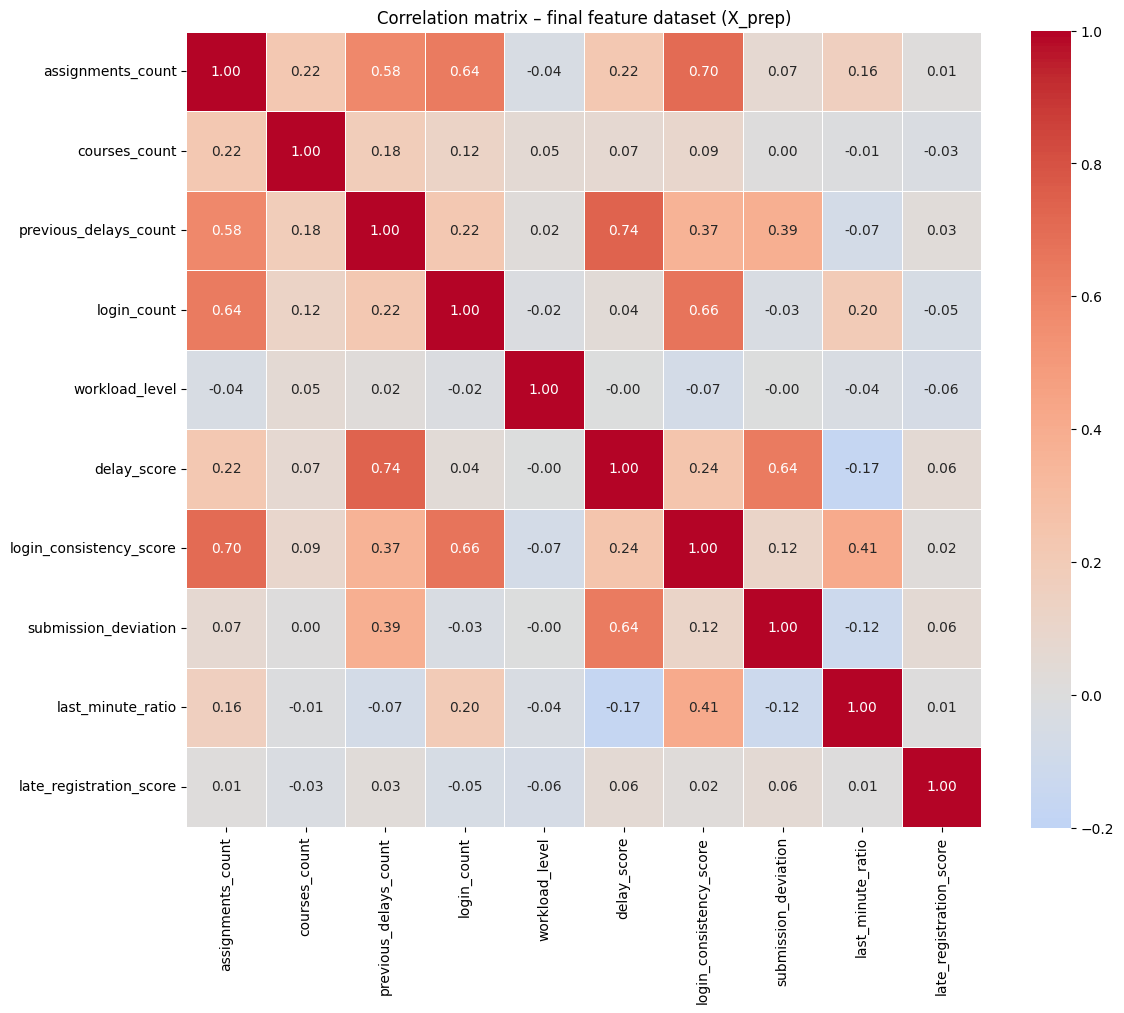

Correlation with label (point-biserial):
delay_score                0.855461
previous_delays_count      0.773213
submission_deviation       0.528874
assignments_count          0.374044
login_consistency_score    0.328310
courses_count              0.204998
login_count                0.125138
last_minute_ratio         -0.069531
late_registration_score    0.051858
workload_level             0.004349


In [15]:
# Imports and correlation matrix (final dataset)
import matplotlib.pyplot as plt
import seaborn as sns

# Use preprocessed feature matrix from Step 5 (X_prep, y_prep)
df_final = X_prep.copy()
df_final["label"] = (
    y_prep.values
)  # 0=low procrastination, 1=high (behavior-based target)
key_features = [
    "delay_score",
    "login_consistency_score",
    "previous_delays_count",
    "assignments_count",
]

# Correlation matrix (fill NaN for constant columns so heatmap is complete)
corr = X_prep.corr()
constant_cols = X_prep.columns[X_prep.std() == 0].tolist()
if constant_cols:
    print(
        "Constant (zero-variance) features:",
        constant_cols,
        "-> correlations shown as 0.",
    )
corr_display = corr.fillna(0)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_display,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-0.2,
    vmax=1.0,
)
plt.title("Correlation matrix – final feature dataset (X_prep)")
plt.tight_layout()
plt.show()
# submission_deviation = mean(late days) from Step 2; delay_score = late count / assignment count (report: Submission Timing Deviation vs Delay Score).
print("Correlation with label (point-biserial):")
label_corr = df_final.corr()["label"].drop("label")
# Drop constant features (NaN correlation) for cleaner display; show them separately
constant = label_corr[label_corr.isna()].index.tolist()
variable = label_corr[label_corr.notna()].reindex(
    label_corr[label_corr.notna()].abs().sort_values(ascending=False).index
)
print(variable.to_string())
if constant:
    print("\nConstant (zero variance) features — correlation undefined:", constant)

### Features that associate with **higher** vs **lower** procrastination

- **Correlation with procrastination label (point-biserial):**  
  - **Positive** correlation → when the feature increases, the student is more likely to be classified as procrastinator (1). So the feature is **associated with higher procrastination** (or with the same behaviors that define the label).  
  - **Negative** correlation → when the feature increases, the student is more likely non-procrastinator (0). So the feature is **associated with lower procrastination** (or with behaviors that reduce it).

- **Model-based view (optional):** Logistic regression coefficients or Random Forest feature importance below confirm direction and relative strength. Correlation is a simple, interpretable first pass; the model adds which features the classifier actually uses.

- **Note:** The procrastination label is defined from `delay_score`, `previous_delays_count`, and `submission_deviation`, so those can be strongly related by construction. Other features (e.g. login_consistency_score, courses_count) show which **context** factors go with higher or lower procrastination.

In [16]:
# Dataset check (X_prep, y_prep from Step 5) and feature–procrastination direction
import pandas as pd
import numpy as np

# 1) Quick dataset sanity
print("=== Dataset check ===")
print("Shape:", X_prep.shape)
print("Missing per column:", X_prep.isnull().sum().to_string())
print(
    "Label distribution (0=low procrastination, 1=high):",
    y_prep.value_counts().to_dict(),
)
print()

# 2) Correlation with procrastination label (same as above; recompute for clarity)
df_final = X_prep.copy()
df_final["label"] = y_prep.values
label_corr = df_final.corr()["label"].drop("label")
# Drop constant (NaN) for interpretation
variable_corr = label_corr[label_corr.notna()].sort_values(ascending=False)

# 3) Classify: positive corr = associated with HIGHER procrastination, negative = LOWER
higher_procrastination = variable_corr[variable_corr > 0].index.tolist()
lower_procrastination = variable_corr[variable_corr < 0].index.tolist()
constant_features = label_corr[label_corr.isna()].index.tolist()

print("=== Features associated with HIGHER procrastination (positive correlation) ===")
for f in higher_procrastination:
    print(f"  {f}: {variable_corr[f]:+.4f}")
print()
print("=== Features associated with LOWER procrastination (negative correlation) ===")
for f in lower_procrastination:
    print(f"  {f}: {variable_corr[f]:+.4f}")
if constant_features:
    print("\nConstant (zero variance) — correlation undefined:", constant_features)

=== Dataset check ===
Shape: (28785, 10)
Missing per column: assignments_count          0
courses_count              0
previous_delays_count      0
login_count                0
workload_level             0
delay_score                0
login_consistency_score    0
submission_deviation       0
last_minute_ratio          0
late_registration_score    0
Label distribution (0=low procrastination, 1=high): {0: 16547, 1: 12238}

=== Features associated with HIGHER procrastination (positive correlation) ===
  delay_score: +0.8555
  previous_delays_count: +0.7732
  submission_deviation: +0.5289
  assignments_count: +0.3740
  login_consistency_score: +0.3283
  courses_count: +0.2050
  login_count: +0.1251
  late_registration_score: +0.0519
  workload_level: +0.0043

=== Features associated with LOWER procrastination (negative correlation) ===
  last_minute_ratio: -0.0695


In [17]:
# Model-based feature direction (Logistic Regression coefficients + Random Forest importance)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Use only variable features (non-constant) for LR; fallback if previous cell not run
try:
    const = constant_features
except NameError:
    const = X_prep.columns[X_prep.std() == 0].tolist()
X_var = X_prep.drop(columns=[c for c in const if c in X_prep.columns], errors="ignore")
if X_var.shape[1] == 0:
    X_var = X_prep
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var.fillna(0))
feat_names = X_var.columns.tolist()

# Logistic Regression: positive coef = higher feature value -> higher P(procrastinator)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y_prep)
lr_coef = pd.Series(lr.coef_.ravel(), index=feat_names).sort_values(ascending=False)
print("=== Logistic Regression coefficients (standardized features) ===")
print("Positive coef -> feature associated with HIGHER procrastination risk:")
print(lr_coef[lr_coef > 0].to_string())
print("\nNegative coef -> feature associated with LOWER procrastination risk:")
print(lr_coef[lr_coef < 0].to_string())

# Random Forest: importance = how much the feature is used to split (magnitude only; direction from LR)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_var.fillna(0), y_prep)
imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
print("\n=== Random Forest feature importance (top predictors) ===")
print(imp.head(12).to_string())

=== Logistic Regression coefficients (standardized features) ===
Positive coef -> feature associated with HIGHER procrastination risk:
delay_score                12.538325
previous_delays_count       9.105802
courses_count               1.263110
submission_deviation        0.962267
assignments_count           0.345497
login_consistency_score     0.170314
workload_level              0.046478
late_registration_score     0.006859

Negative coef -> feature associated with LOWER procrastination risk:
login_count         -0.032809
last_minute_ratio   -0.681864

=== Random Forest feature importance (top predictors) ===
delay_score                0.416776
submission_deviation       0.262915
previous_delays_count      0.233844
assignments_count          0.048154
last_minute_ratio          0.017643
login_consistency_score    0.007584
login_count                0.006574
courses_count              0.004525
workload_level             0.001276
late_registration_score    0.000708


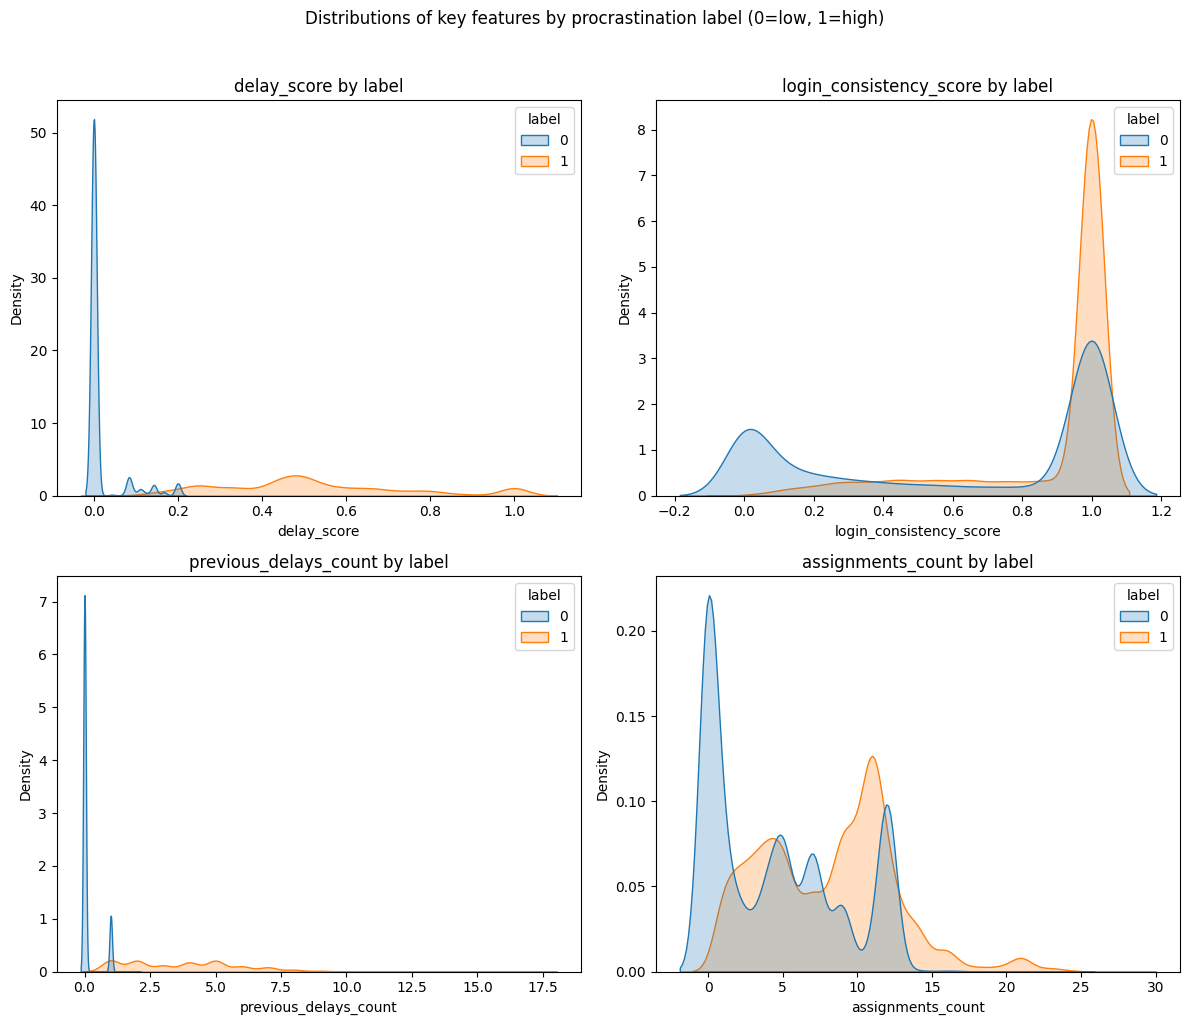

In [18]:
# Distributions: key features by label (KDE / histogram); key_features from cell above
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, col in zip(axes, key_features):
    sns.kdeplot(
        data=df_final,
        x=col,
        hue="label",
        fill=True,
        common_norm=False,
        ax=ax,
        legend=True,
    )
    ax.set_title(f"{col} by label")
    ax.set_xlabel(col)
plt.suptitle(
    "Distributions of key features by procrastination label (0=low, 1=high)", y=1.02
)
plt.tight_layout()
plt.show()

C:\Users\MC\AppData\Local\Temp\ipykernel_12904\2396236421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="label", y=col, ax=ax, palette="Set2")
C:\Users\MC\AppData\Local\Temp\ipykernel_12904\2396236421.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low", "High"])  # procrastination label
C:\Users\MC\AppData\Local\Temp\ipykernel_12904\2396236421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="label", y=col, ax=ax, palette="Set2")
C:\Users\MC\AppData\Local\Temp\ipykernel_12904\2396236421.py:7: UserWarning: set_ticklabels() should only be us

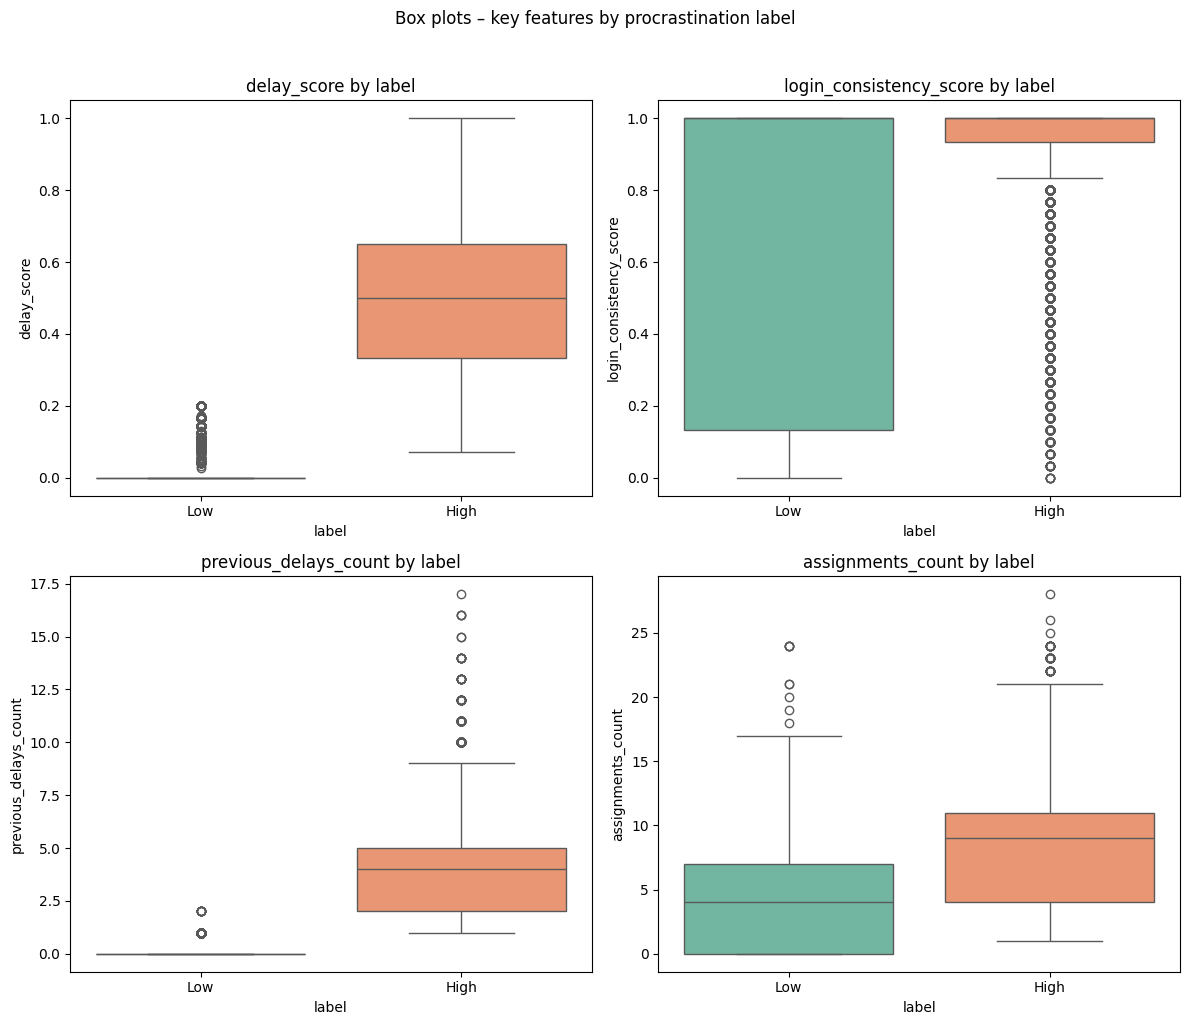

In [19]:
# Box plots: features by label (sns)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, col in zip(axes, key_features):
    sns.boxplot(data=df_final, x="label", y=col, ax=ax, palette="Set2")
    ax.set_title(f"{col} by label")
    ax.set_xticklabels(["Low", "High"])  # procrastination label
plt.suptitle("Box plots – key features by procrastination label", y=1.02)
plt.tight_layout()
plt.show()

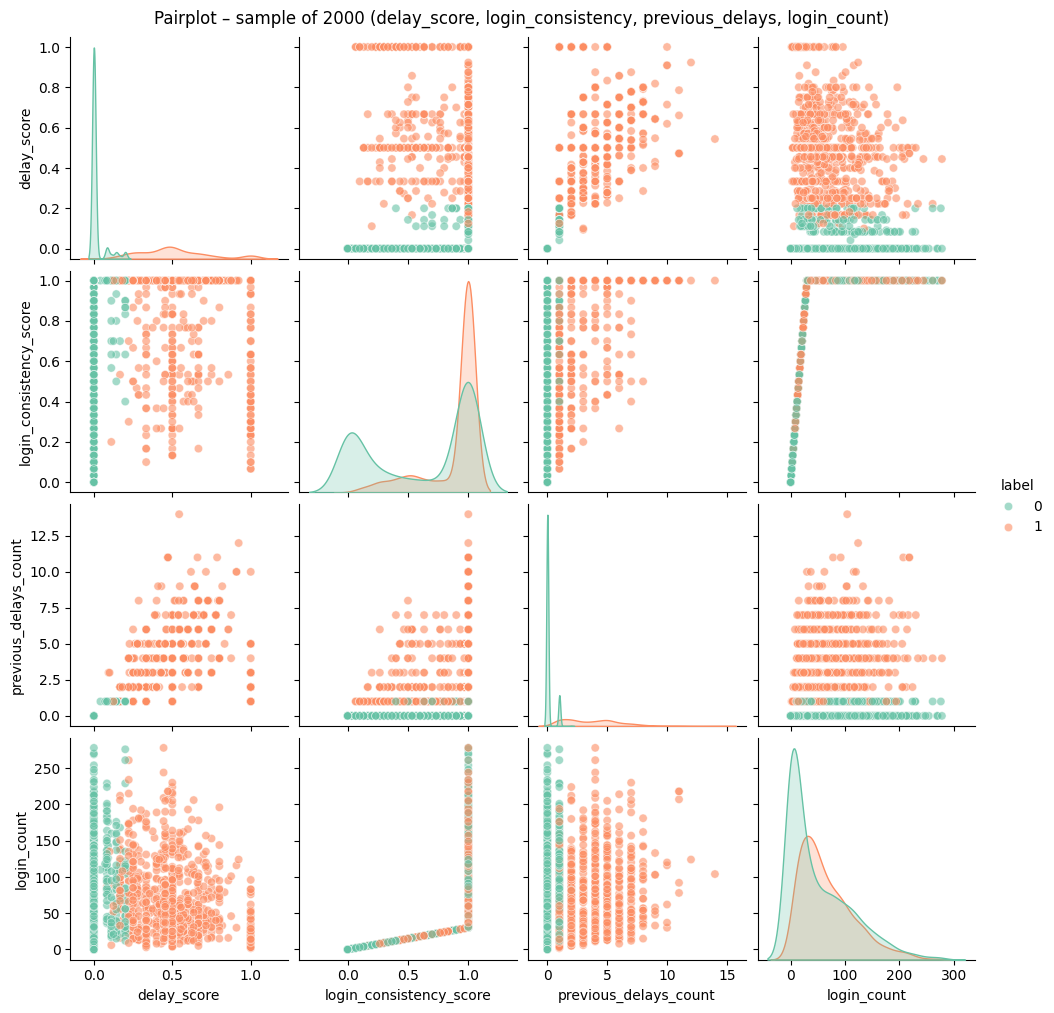

In [20]:
# Pairplot (sample for speed): selected features vs label
sample = df_final.sample(n=min(2000, len(df_final)), random_state=42)
pair_cols = [
    "delay_score",
    "login_consistency_score",
    "previous_delays_count",
    "login_count",
    "label",
]
sns.pairplot(
    sample[pair_cols],
    hue="label",
    palette="Set2",
    diag_kind="kde",
    plot_kws={"alpha": 0.6},
)
plt.suptitle(
    "Pairplot – sample of 2000 (delay_score, login_consistency, previous_delays, login_count)",
    y=1.01,
)
plt.show()